# Matplotlib基础

## 课程简介

欢迎来到“Matplotlib 基础”课程。Matplotlib 是 Python 中最著名的数据可视化库之一，它能让你仅用几行代码就创建出高质量的图表，从而高效、美观地展示数据。本课程面向本科生，旨在用80分钟的时间，带你掌握 Matplotlib 的核心概念和基本操作，为后续的数据分析和科学研究打下坚实的基础。

**课程目标：**
1. 掌握 Matplotlib 绘图的基本流程。
2. 熟练运用 `plt.plot()` 和 `plt.scatter()` 绘制常见图形。
3. 理解并应用图形布局（如 `subplot`）来组织多个图表。
4. 学会通过添加标签、标题、图例等美化图表。
5. 通过实训案例，将所学知识应用于实际数据可视化。

---

## 1. 绘制图形

### 1.1 Matplotlib 绘图基本流程

Matplotlib 的绘图过程可以概括为几个核心步骤。理解这个流程是高效绘图的关键。

```mermaid
graph LR
    A[导入Matplotlib] --> B[准备数据]
    B --> C[创建图形和坐标轴]
    C --> D[绘制图形]
    D --> E[设置标签和样式]
    E --> F[显示或保存图形]
```

绘图的第一步是导入 `matplotlib.pyplot` 模块，通常简写为 `plt`。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# 导入 numpy 用于生成数据

Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 801 ('font.family: sans-serif')
Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 802 ('font.sans-serif: SimHei')


### 1.2 绘制线图（`plt.plot`）
`plt.plot()` 是最基础的绘图函数，用于绘制线图和标记点。

**基本用法：**
- `plt.plot(y)`：只给定 Y 轴数据，X 轴默认使用数据的索引（0, 1, 2, ...）。
- `plt.plot(x, y)`：给定 X 轴和 Y 轴数据，绘制 (x, y) 对应的曲线。

**示例：绘制正弦函数**

/home/jovyan/.virtualenvs/basenv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


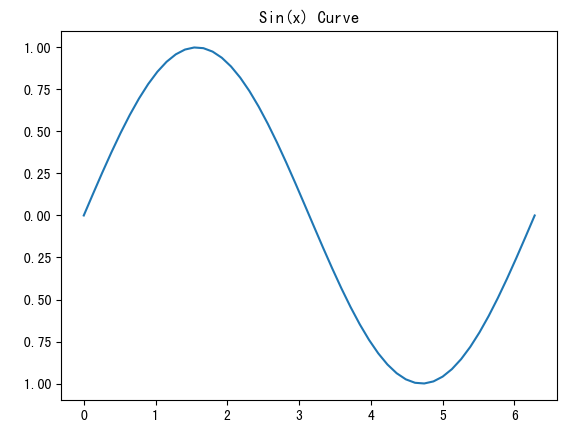

In [2]:
x = np.linspace(0, 2 * np.pi, 50) # 生成0到2π之间的50个点
y = np.sin(x)
plt.plot(x, y)
plt.title('Sin(x) Curve')
plt.show()

**线条样式定制：**           
Matplotlib 允许使用格式字符串（Format String）来快速定制线条的颜色、标记和线型。格式字符串的结构是 `[颜色][标记][线型]`。

| 颜色 (Color) | 标记 (Marker) | 线型 (Line Style) |
| :---: | :---: | :---: |
| `'r'` (Red) | `'o'` (Circle) | `'-'` (Solid line) |
| `'b'` (Blue) | `'^'` (Triangle up) | `'--'` (Dashed line) |
| `'g'` (Green) | `'s'` (Square) | `':'` (Dotted line) |

**示例：多条曲线和样式**

/tmp/ipykernel_105/3351202155.py:6: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.savefig('plot_example.png') # 保存图片


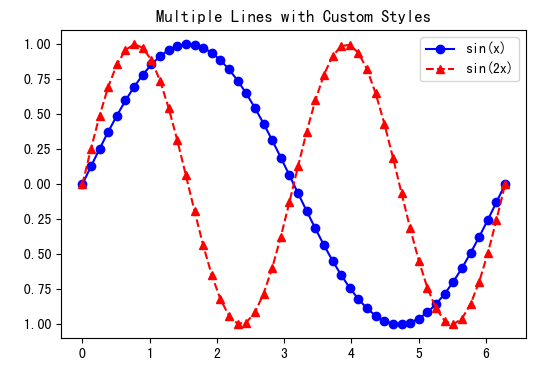

In [3]:
plt.figure(figsize=(6, 4))
plt.plot(x, np.sin(x), 'b-o', label='sin(x)') # 蓝色实线，圆点标记
plt.plot(x, np.sin(2 * x), 'r--^', label='sin(2x)') # 红色虚线，三角标记
plt.legend() # 显示图例
plt.title('Multiple Lines with Custom Styles')
plt.show()

### 1.3 绘制散点图（`plt.scatter`）
散点图用于展示两个变量之间的关系，特别适合展示数据点的分布。

**基本用法：**
`plt.scatter(x, y)`：绘制 (x, y) 坐标处的散点。

**高级定制：**
`plt.scatter()` 相比 `plt.plot()` 更加灵活，可以为每个点单独设置大小（`s`）和颜色（`c`）。

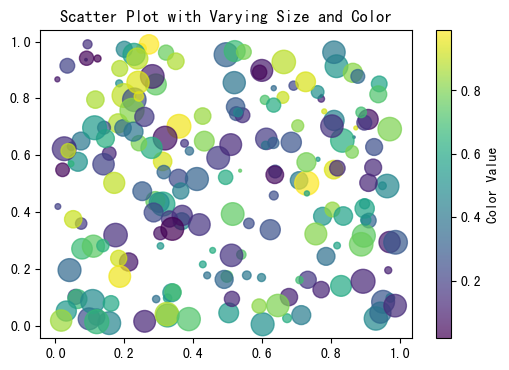

In [4]:
np.random.seed(42)
x_scatter = np.random.rand(200)
y_scatter = np.random.rand(200)
size = np.random.rand(200) * 300 # 随机大小
color = np.random.rand(200) # 随机颜色值

plt.figure(figsize=(6, 4))
plt.scatter(x_scatter, y_scatter, s=size, c=color, alpha=0.7, cmap='viridis')
plt.colorbar(label='Color Value') # 添加颜色条
plt.title('Scatter Plot with Varying Size and Color')
plt.show()

### 1.4 Matplotlib 图表类型对比表格
上面两个图是最简单的图表模式，下面这张表展示了 Matplotlib 常用的一些表。

| 图表类型 | 适用场景 | 优点 | 缺点 | 示例代码关键函数 | 主要参数 |
|---------|---------|------|------|-----------------|----------|
| **饼图**<br>Pie Chart | 显示各部分占比关系<br>构成分析 | 直观显示比例<br>易于理解占比 | 不擅长精确数值比较<br>类别不宜过多 | `plt.pie()` | `sizes`, `labels`, `autopct`, `explode`, `colors` |
| **柱状图**<br>Bar Chart | 比较不同类别数据<br>数值对比 | 精确比较数值<br>易于阅读 | 类别过多时拥挤<br>无法显示趋势 | `plt.bar()` | `x`, `height`, `color`, `width`, `alpha` |
| **水平柱状图**<br>Horizontal Bar | 类别名称较长时<br>较多类别比较 | 长标签易读<br>空间利用率高 | 数值比较不如垂直直观 | `plt.barh()` | `y`, `width`, `color`, `height` |
| **折线图**<br>Line Plot | 时间序列分析<br>趋势变化 | 清晰展示趋势<br>支持多线对比 | 不适合分类数据<br>数据点稀疏时失真 | `plt.plot()` | `x`, `y`, `color`, `marker`, `linewidth` |
| **堆叠柱状图**<br>Stacked Bar | 显示总量和构成<br>部分与整体关系 | 同时显示总量和构成<br>便于比较累积值 | 各部分比较困难<br>底部变化影响上部 | `plt.bar()` + `bottom` | `bottom`参数堆叠 |
| **散点图**<br>Scatter Plot | 变量相关性分析<br>分布关系 | 展示相关性<br>发现异常值 | 无法显示时间趋势<br>过度绘制问题 | `plt.scatter()` | `x`, `y`, `s`, `c`, `alpha` |
| **面积图**<br>Area Chart | 累积趋势展示<br>变化幅度强调 | 强调变化幅度<br>视觉效果强 | 底部数据被遮盖<br>阅读精确值困难 | `plt.stackplot()` | `x`, `y1,y2...`, `colors`, `labels` |
| **箱线图**<br>Box Plot | 数据分布特征<br>统计指标展示 | 显示多个统计量<br>识别异常值 | 不显示数据分布形状<br>需要统计知识 | `plt.boxplot()` | `x`, `labels`, `patch_artist` |



## 2. 图形布局

### 2.1 创建新的画布（`plt.figure`）

默认情况下，所有的绘图命令都会在同一个画布（Figure）上进行。如果需要创建新的独立图表，可以使用 `plt.figure()`。


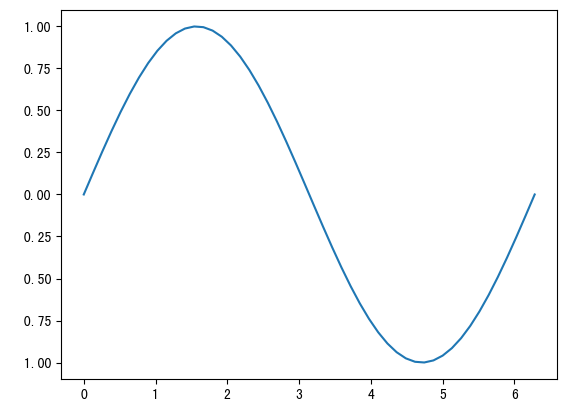

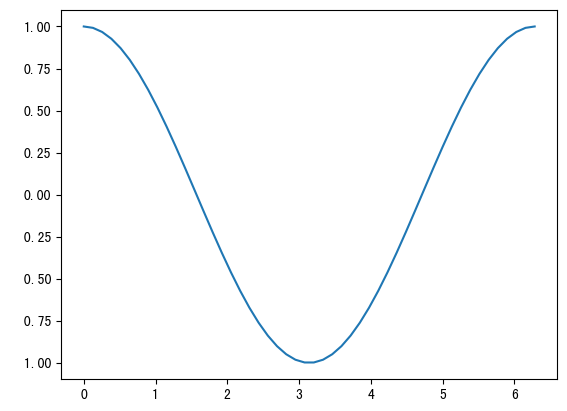

In [5]:
# 绘制第一个图
plt.figure(1)
plt.plot(x, np.sin(x))

# 绘制第二个图
plt.figure(2)
plt.plot(x, np.cos(x))
plt.show()

### 2.2 子图（`plt.subplot`）
在单个画布上绘制多个子图（Axes）是数据可视化中常见的需求。`plt.subplot()` 函数可以实现这个功能。

**用法：**
`plt.subplot(nrows, ncols, index)`

- `nrows`：行数。
- `ncols`：列数。
- `index`：子图的索引（从1开始计数，从左到右，从上到下）。

**示例：水平排列的两个子图**

/tmp/ipykernel_105/825157108.py:17: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout() # 自动调整子图参数，使之填充整个图像区域
/tmp/ipykernel_105/825157108.py:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.savefig('subplot_example.png')


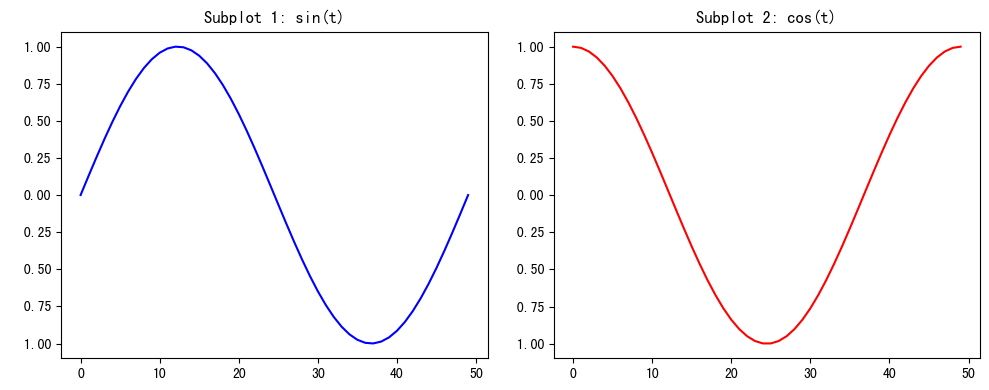

In [6]:
t = np.linspace(0, 2 * np.pi, 50)
x_t = np.sin(t)
y_t = np.cos(t)

plt.figure(figsize=(10, 4))

# 第一个子图：1行2列中的第1个
plt.subplot(1, 2, 1)
plt.plot(x_t, color='blue')
plt.title('Subplot 1: sin(t)')

# 第二个子图：1行2列中的第2个
plt.subplot(1, 2, 2)
plt.plot(y_t, color='red')
plt.title('Subplot 2: cos(t)')

plt.tight_layout() # 自动调整子图参数，使之填充整个图像区域
plt.show()

## 3. 图形美化 

### 3.1 添加标签和标题
一个好的图表必须包含清晰的标签和标题，以便读者理解图表所表达的内容。

| 功能 | 函数 | 描述 |
| :---: | :---: | :---: |
| X轴标签 | `plt.xlabel('Label')` | 设置 X 轴的名称 |
| Y轴标签 | `plt.ylabel('Label')` | 设置 Y 轴的名称 |
| 图表标题 | `plt.title('Title')` | 设置整个图表的标题 |

**示例：**


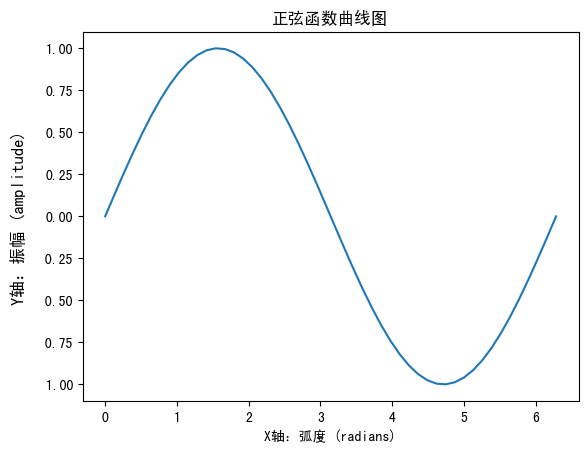

In [7]:
plt.plot(x, np.sin(x))
plt.xlabel('X轴：弧度 (radians)')
plt.ylabel('Y轴：振幅 (amplitude)', fontsize='large') # 可以设置字体大小
plt.title('正弦函数曲线图')
plt.show()

### 3.2 添加图例（`plt.legend`）
当图表中有多个数据系列时，图例（Legend）用于区分它们。

**用法：**
1. 在 `plt.plot()` 或 `plt.scatter()` 中使用 `label` 参数为每个系列命名。
2. 调用 `plt.legend()` 来显示图例。


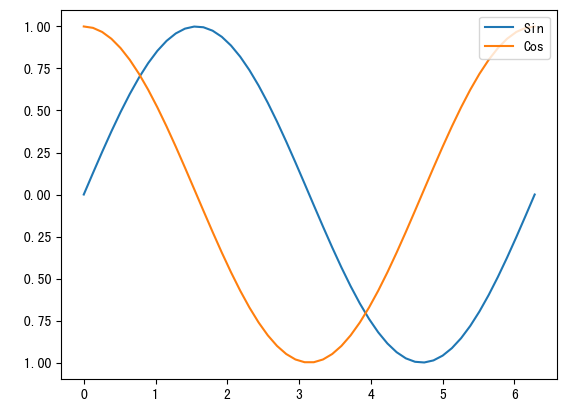

In [8]:
plt.plot(x, np.sin(x), label='Sin')
plt.plot(x, np.cos(x), label='Cos')
plt.legend(loc='upper right') # loc 参数可以控制图例的位置
plt.show()

### 3.3 添加网格（`plt.grid`）
网格线可以帮助读者更精确地读取图表中的数值。

**用法：**
`plt.grid(True)`：显示网格线。

**示例：**


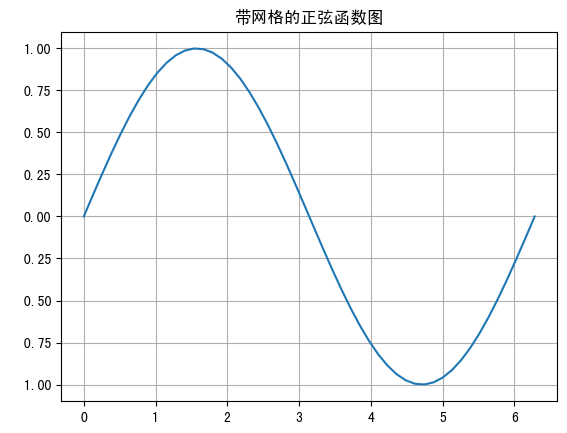

In [9]:
plt.plot(x, np.sin(x))
plt.title('带网格的正弦函数图')
plt.grid(True)
plt.show()

### 3.4 绘制直方图（`plt.hist`）
直方图用于展示数据的分布情况。

**用法：**
`plt.hist(data, bins=n)`：绘制数据的直方图，`bins` 参数指定了直方图的条数。

/tmp/ipykernel_105/2362706138.py:9: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.savefig('histogram_example.png')


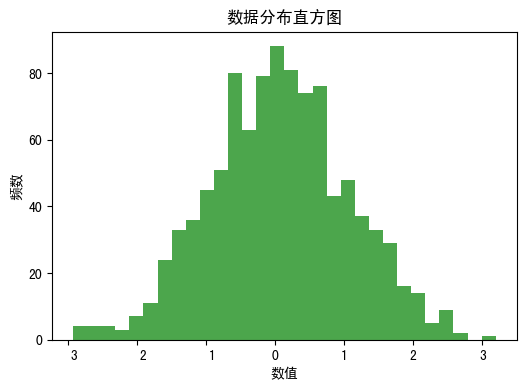

In [10]:
# 从标准正态分布中随机生成1000个点
data = np.random.randn(1000)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, color='green', alpha=0.7)
plt.title('数据分布直方图')
plt.xlabel('数值')
plt.ylabel('频数')
plt.show()